<a href="https://colab.research.google.com/github/Ayush-thakur-01/Ml/blob/main/assignment_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("/content/car data.csv")

print("Shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary:\n", df.describe())

Shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Summary:
               Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.0000

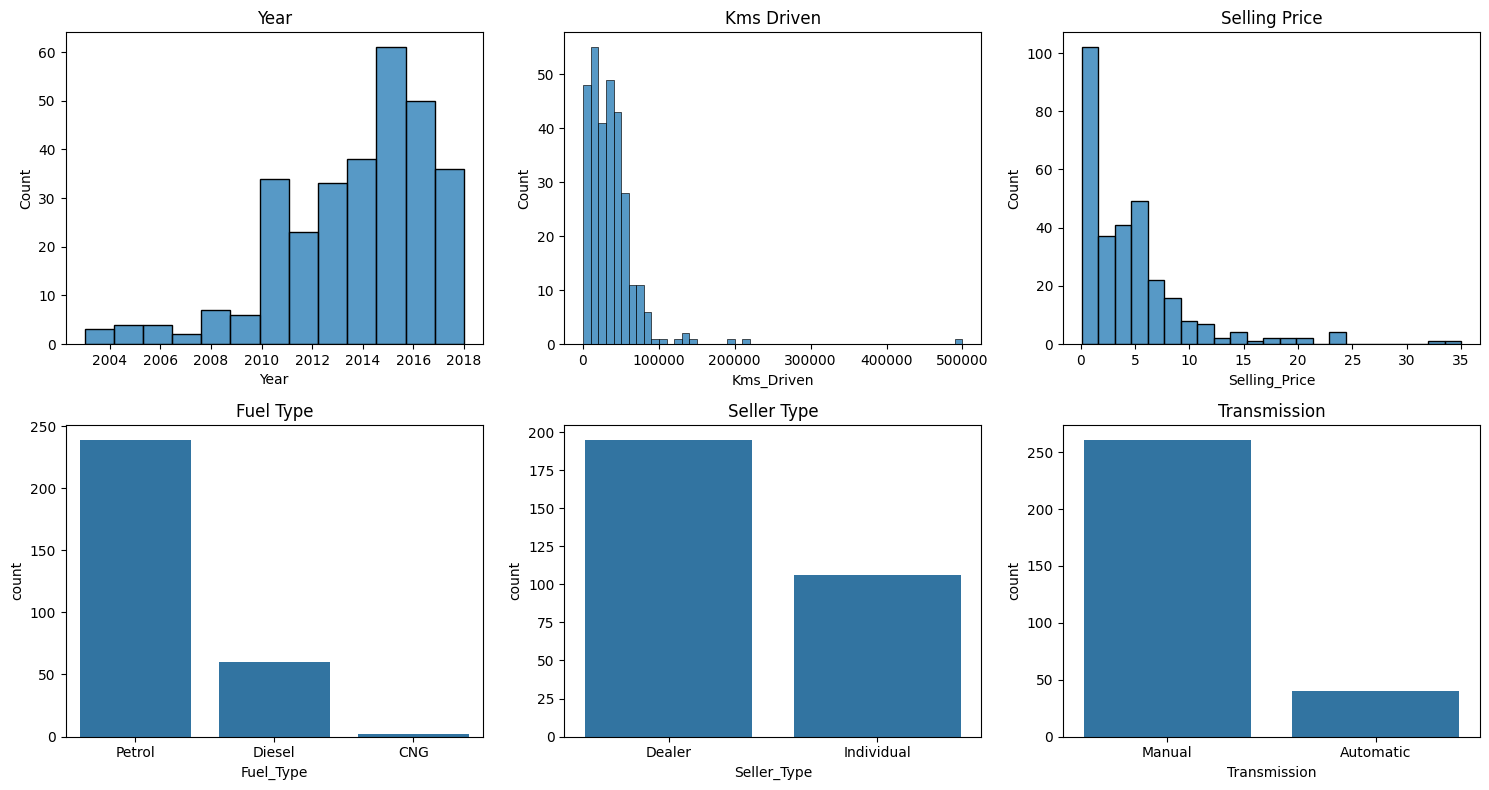

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["Year"], ax=ax[0,0])
ax[0,0].set_title("Year")

sns.histplot(df["Kms_Driven"], ax=ax[0,1])
ax[0,1].set_title("Kms Driven")

sns.histplot(df["Selling_Price"], ax=ax[0,2])
ax[0,2].set_title("Selling Price")

sns.countplot(data=df, x="Fuel_Type", ax=ax[1,0])
ax[1,0].set_title("Fuel Type")

sns.countplot(data=df, x="Seller_Type", ax=ax[1,1])
ax[1,1].set_title("Seller Type")

sns.countplot(data=df, x="Transmission", ax=ax[1,2])
ax[1,2].set_title("Transmission")

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(["Selling_Price", "Car_Name"], axis=1)
y = df["Selling_Price"]

cat = ["Fuel_Type", "Seller_Type", "Transmission"]
num = ["Year", "Present_Price", "Kms_Driven", "Owner"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(X_train.shape, X_test.shape)

(240, 11) (61, 11)


In [ ]:
ridge_grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)
ridge = ridge_grid.best_estimator_

print("Best Ridge Alpha:", ridge_grid.best_params_["alpha"])

Best Ridge Alpha: 10


In [ ]:
lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_grid.fit(X_train, y_train)
lasso = lasso_grid.best_estimator_

print("Best Lasso Alpha:", lasso_grid.best_params_["alpha"])

Best Lasso Alpha: 0.001


In [ ]:
models = {"Ridge": ridge, "Lasso": lasso}

for name, model in models.items():
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(
        name,
        "| MSE:", round(mse, 4),
        "| RMSE:", round(np.sqrt(mse), 4),
        "| MAE:", round(mean_absolute_error(y_test, pred), 4),
        "| R²:", round(r2_score(y_test, pred), 4)
    )

Ridge | MSE: 3.5778 | RMSE: 1.8915 | MAE: 1.2218 | R²: 0.8447
Lasso | MSE: 3.4769 | RMSE: 1.8646 | MAE: 1.2158 | R²: 0.8491


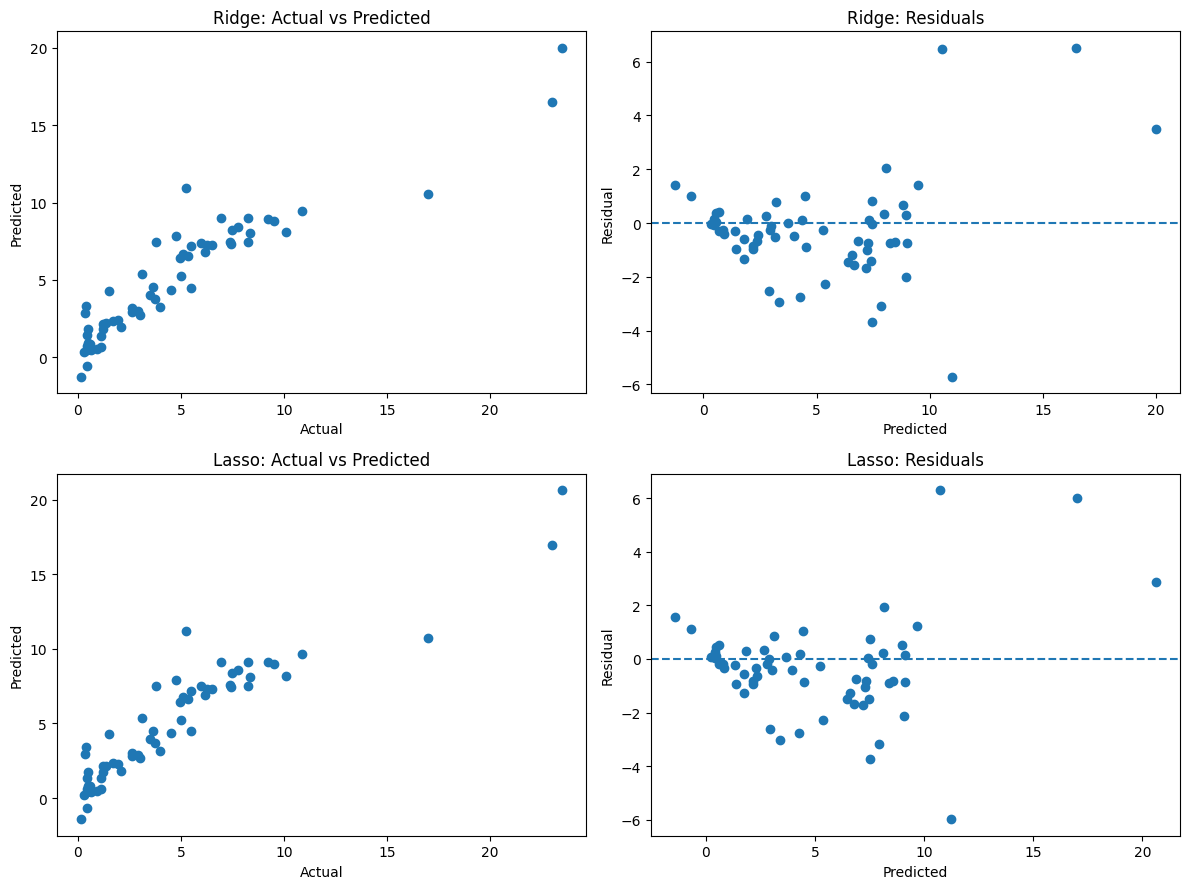

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))

for i, (name, model) in enumerate(models.items()):
    pred = model.predict(X_test)
    res = y_test - pred

    ax[i,0].scatter(y_test, pred)
    ax[i,0].set_title(f"{name}: Actual vs Predicted")
    ax[i,0].set_xlabel("Actual")
    ax[i,0].set_ylabel("Predicted")

    ax[i,1].scatter(pred, res)
    ax[i,1].axhline(0, linestyle="--")
    ax[i,1].set_title(f"{name}: Residuals")
    ax[i,1].set_xlabel("Predicted")
    ax[i,1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

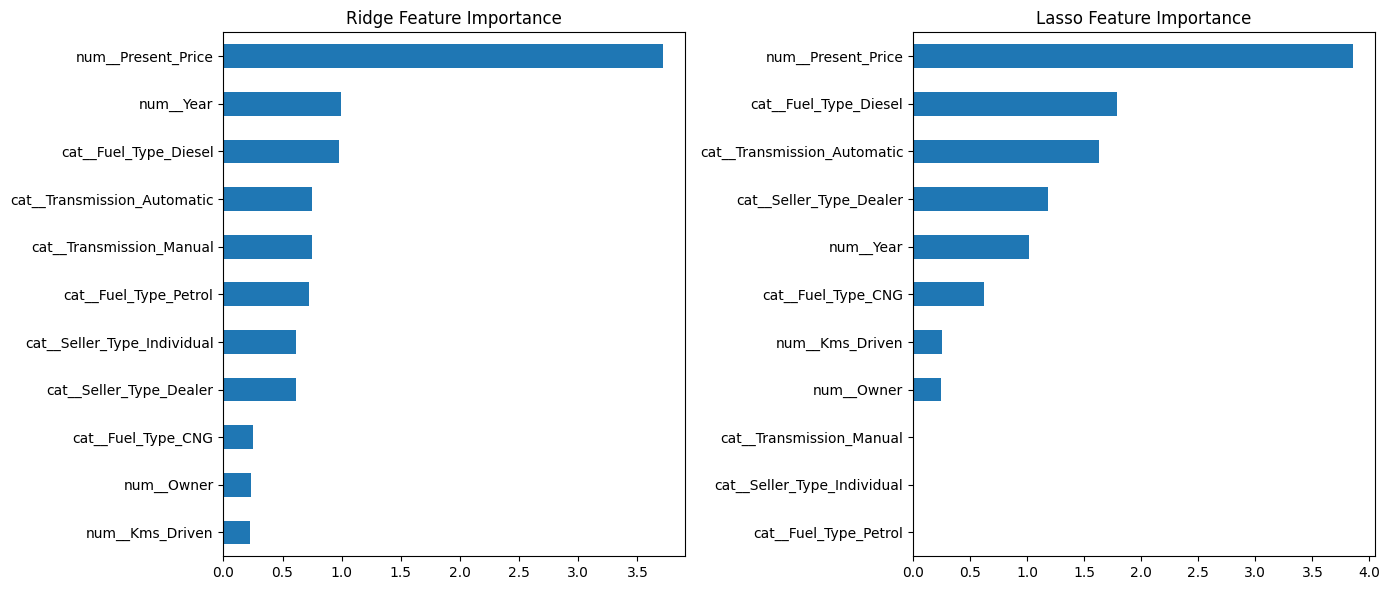

In [ ]:
features = preprocessor.get_feature_names_out()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, model) in enumerate(models.items()):
    imp = pd.Series(abs(model.coef_), index=features).sort_values()
    imp.plot.barh(ax=ax[i])
    ax[i].set_title(f"{name} Feature Importance")

plt.tight_layout()
plt.show()

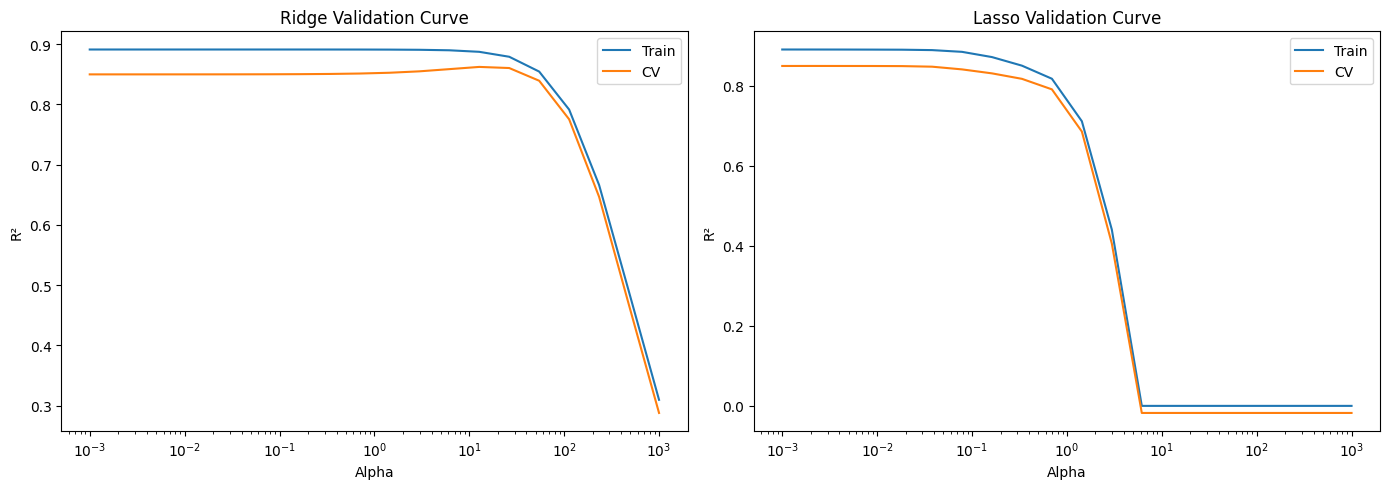

In [ ]:
alphas = np.logspace(-3, 3, 20)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, model) in enumerate([( "Ridge", Ridge()), ("Lasso", Lasso(max_iter=10000))]):
    train, cv = validation_curve(
        model, X_train, y_train,
        param_name="alpha",
        param_range=alphas,
        cv=5,
        scoring="r2"
    )

    ax[i].semilogx(alphas, train.mean(axis=1), label="Train")
    ax[i].semilogx(alphas, cv.mean(axis=1), label="CV")
    ax[i].set_title(f"{name} Validation Curve")
    ax[i].set_xlabel("Alpha")
    ax[i].set_ylabel("R²")
    ax[i].legend()

plt.tight_layout()
plt.show()

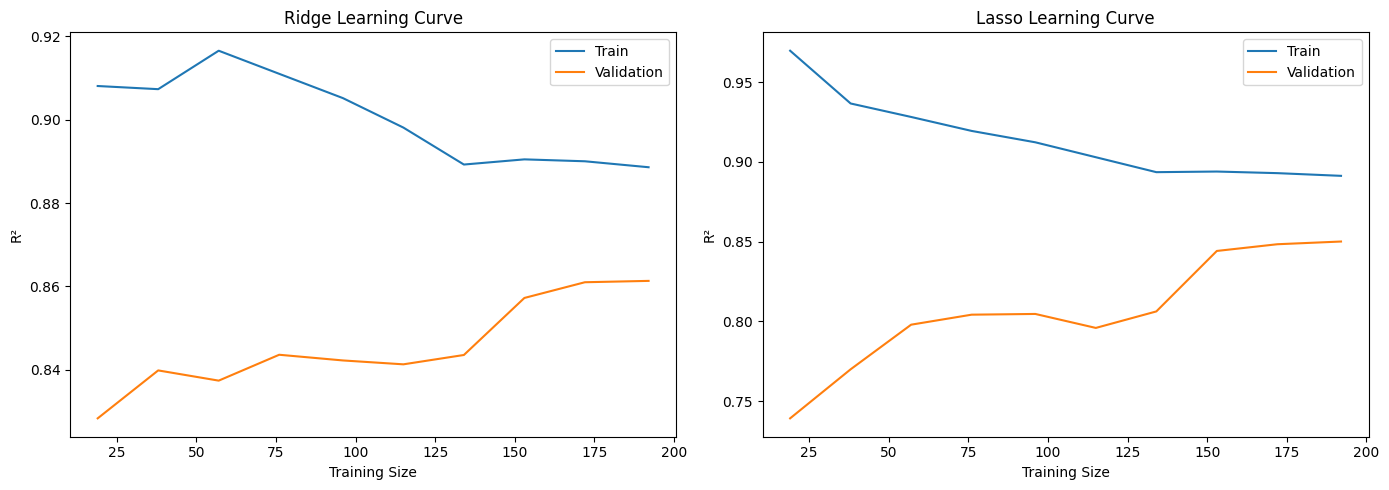

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, model) in enumerate(models.items()):
    size, train, cv = learning_curve(
        model, X_train, y_train,
        cv=5,
        train_sizes=np.linspace(.1, 1, 10),
        scoring="r2"
    )

    ax[i].plot(size, train.mean(axis=1), label="Train")
    ax[i].plot(size, cv.mean(axis=1), label="Validation")
    ax[i].set_title(f"{name} Learning Curve")
    ax[i].set_xlabel("Training Size")
    ax[i].set_ylabel("R²")
    ax[i].legend()

plt.tight_layout()
plt.show()

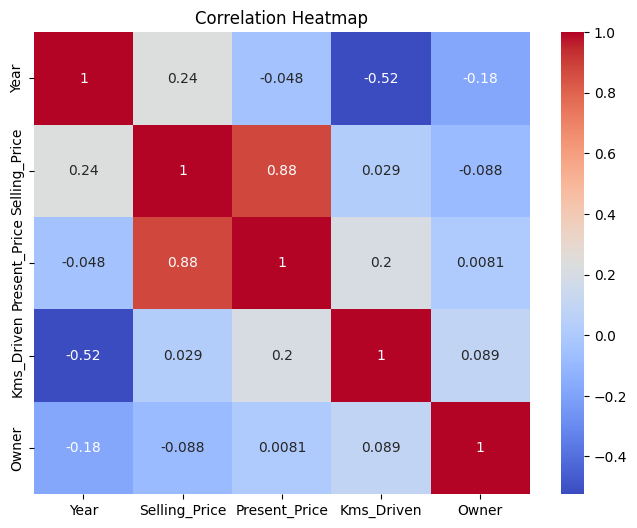

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
for test_size in [0.4, 0.3, 0.1]:
    Xt, Xv, yt, yv = train_test_split(
        df.drop(["Selling_Price", "Car_Name"], axis=1),
        y, test_size=test_size, random_state=42
    )

    p = preprocessor.fit_transform(Xt)
    v = preprocessor.transform(Xv)

    model = Ridge(alpha=10).fit(p, yt)
    print(f"{int((1-test_size)*100)}/{int(test_size*100)} R²:",
          round(r2_score(yv, model.predict(v)), 4))

60/40 R²: 0.8497
70/30 R²: 0.8683
90/10 R²: 0.8215
